## 12. Generate Feature Weights Code for Algorithm

Extract feature weights and generate Python code ready to paste into `algorithms/macd_rsi_algorithm.py`

# Signals-Orders Analysis: Predicting Win/Loss

This notebook analyzes signals from MLflow to identify which signal characteristics predict winning trades.

**Objectives:**
1. Load signals_orders_dataframe.csv from MLflow
2. Perform exploratory data analysis (EDA)
3. Calculate correlations with `is_win`
4. Train ML models to predict trade outcomes
5. Identify most important features for winning trades

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# MLflow
import mlflow
from mlflow.tracking import MlflowClient

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    precision_recall_curve,
    f1_score
)

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")

✅ All imports successful!


## 1. Load Data from MLflow

Configure MLflow and download the signals_orders_dataframe.csv

In [2]:
# MLflow configuration
MLFLOW_TRACKING_URI = "http://hp.lan:8899"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Artifact path - update this with your run ID
# Format: "mlflow-artifacts:/{experiment_id}/{run_id}/artifacts/signals_orders_dataframe.csv"
ARTIFACT_PATH = "mlflow-artifacts:/478886415386718522/586fe9512b634ffba46eab458a41d3b5/artifacts/signals_orders_dataframe.csv"

# Alternative: Use run_id directly
RUN_ID = "586fe9512b634ffba46eab458a41d3b5"  # Update with your run ID

print(f"MLflow Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Run ID: {RUN_ID}")

MLflow Tracking URI: http://hp.lan:8899
Run ID: 586fe9512b634ffba46eab458a41d3b5


In [3]:
# Method 1: Download using artifact path
try:
    print("Downloading artifact from MLflow...")
    local_path = mlflow.artifacts.download_artifacts(
        artifact_uri=ARTIFACT_PATH
    )
    print(f"✅ Downloaded to: {local_path}")
except Exception as e:
    print(f"Method 1 failed: {e}")
    print("\nTrying Method 2: Download using run_id...")
    
    # Method 2: Download using run_id and artifact path
    local_path = mlflow.artifacts.download_artifacts(
        run_id=RUN_ID,
        artifact_path="signals_orders_dataframe.csv"
    )
    print(f"✅ Downloaded to: {local_path}")

✅ Downloaded to: C:\Users\pablo\AppData\Local\Temp\tmpnl9u18ph\signals_orders_dataframe.csv


In [4]:
# Load into DataFrame
df = pd.read_csv(local_path)

print(f"✅ Loaded DataFrame: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

✅ Loaded DataFrame: 1081 rows × 63 columns

Columns: ['timestamp', 'signal_type', 'symbol', 'signal_strength', 'signal_rsi.period', 'signal_rsi.rsi', 'signal_rsi.avg_gain', 'signal_rsi.avg_loss', 'signal_rsi.rs', 'signal_macd.slow_period', 'signal_macd.fast_period', 'signal_macd.signal_period', 'signal_macd.slow_ema', 'signal_macd.fast_ema', 'signal_macd.macd', 'signal_macd.signal', 'signal_macd.histogram', 'signal_macd.last_macd', 'signal_macd_last.slow_period', 'signal_macd_last.fast_period', 'signal_macd_last.signal_period', 'signal_macd_last.slow_ema', 'signal_macd_last.fast_ema', 'signal_macd_last.macd', 'signal_macd_last.signal', 'signal_macd_last.histogram', 'signal_macd_last.last_macd', 'order_id', 'order_type', 'order_status', 'is_bracket_order', 'entry_price', 'entry_quantity', 'entry_cost', 'entry_tx_cost', 'entry_total', 'entry_datetime', 'has_exit', 'exit_price', 'exit_quantity', 'exit_proceeds', 'exit_tx_cost', 'exit_total', 'exit_datetime', 'exit_type', 'exit_reason', 'n

,timestamp,signal_type,symbol,signal_strength,signal_rsi.period,signal_rsi.rsi,signal_rsi.avg_gain,signal_rsi.avg_loss,signal_rsi.rs,signal_macd.slow_period,...,entry_day_of_week,exit_hour,exit_day_of_week,price_change_pct,total_return,stop_loss_price,profit_target_price,risk_pct,reward_pct,risk_reward_ratio
0,2022-01-06 00:55:00+00:00,BUY,UPRO,100,14,51.376165,NaN,NaN,NaN,117,...,Thursday,15.0,Thursday,-1.267721,941.59,72.4300,74.0936,1.267721,1.000000,0.788817
1,2022-01-07 00:15:00+00:00,BUY,UPRO,100,14,65.756641,NaN,NaN,NaN,117,...,Friday,9.0,Friday,-1.305057,943.80,72.6000,74.2956,1.305057,1.000000,0.766250
2,2022-01-07 18:25:00+00:00,BUY,UPRO,100,14,52.284099,NaN,NaN,NaN,117,...,Friday,11.0,Monday,-1.200166,931.06,71.6200,73.2149,1.200166,1.000000,0.833218
3,2022-01-10 18:25:00+00:00,BUY,UPRO,100,14,63.866752,NaN,NaN,NaN,117,...,Monday,19.0,Monday,1.296083,914.42,68.7456,70.3400,1.000000,1.296083,1.296083
4,2022-01-11 17:40:00+00:00,BUY,UPRO,100,14,58.601847,NaN,NaN,NaN,117,...,Tuesday,19.0,Tuesday,1.131971,952.38,71.7156,73.2600,1.000000,1.131971,1.131971


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Basic info
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Total signals: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types
print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes.value_counts())

# Missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing[missing > 0],
    'Percent': missing_pct[missing > 0]
}).sort_values('Percent', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values!")

DATASET OVERVIEW
Total signals: 1081
Date range: 2022-01-06 00:55:00+00:00 to 2025-11-19 21:15:00+00:00

Columns: 63
Memory usage: 1.41 MB

DATA TYPES
float64    34
object     14
int64      13
bool        2
Name: count, dtype: int64

MISSING VALUES
                            Missing  Percent
signal_rsi.avg_gain            1081   100.00
signal_rsi.avg_loss            1081   100.00
signal_rsi.rs                  1081   100.00
signal_macd_last.last_macd     1081   100.00
exit_price                      274    25.35
exit_quantity                   274    25.35
exit_proceeds                   274    25.35
exit_tx_cost                    274    25.35
exit_total                      274    25.35
exit_datetime                   274    25.35
exit_type                       274    25.35
exit_reason                     274    25.35
net_pnl                         274    25.35
net_pnl_pct                     274    25.35
is_win                          274    25.35
duration_seconds               

In [6]:
# Check for required columns
print("=" * 80)
print("CHECKING DATA STRUCTURE")
print("=" * 80)
print(f"\nAvailable columns ({len(df.columns)}):")
for col in sorted(df.columns):
    print(f"  - {col}")

# Check for is_win column
if 'is_win' not in df.columns:
    print("\n⚠️ WARNING: 'is_win' column not found!")
    
    # Try to create it from net_pnl
    if 'net_pnl' in df.columns:
        print("Creating 'is_win' column from 'net_pnl'...")
        df['is_win'] = df['net_pnl'] > 0
        print("✅ 'is_win' column created (True if net_pnl > 0)")
    elif 'net_pnl_pct' in df.columns:
        print("Creating 'is_win' column from 'net_pnl_pct'...")
        df['is_win'] = df['net_pnl_pct'] > 0
        print("✅ 'is_win' column created (True if net_pnl_pct > 0)")
    else:
        print("❌ ERROR: Cannot create 'is_win' column - no P&L columns found!")
        print("Available columns:", list(df.columns))
        raise ValueError("DataFrame must have 'is_win', 'net_pnl', or 'net_pnl_pct' column")
else:
    print("\n✅ 'is_win' column found")

# Check for has_exit column
if 'has_exit' not in df.columns:
    print("\n⚠️ WARNING: 'has_exit' column not found!")
    
    # Try to infer from exit_price or exit_datetime
    if 'exit_price' in df.columns:
        print("Creating 'has_exit' column from 'exit_price'...")
        df['has_exit'] = df['exit_price'].notna()
        print("✅ 'has_exit' column created")
    elif 'exit_datetime' in df.columns:
        print("Creating 'has_exit' column from 'exit_datetime'...")
        df['has_exit'] = df['exit_datetime'].notna()
        print("✅ 'has_exit' column created")
    else:
        print("Creating 'has_exit' column (assuming all trades completed)...")
        df['has_exit'] = True
        print("✅ 'has_exit' column created (all set to True)")
else:
    print("✅ 'has_exit' column found")

# Filter to completed trades only (has exit)
df_completed = df[df['has_exit'] == True].copy()
print(f"\nTotal trades: {len(df)}")
print(f"Completed trades: {len(df_completed)} ({len(df_completed)/len(df)*100:.1f}%)")
print(f"Incomplete trades: {len(df) - len(df_completed)}")

# Use completed trades for analysis
df_analysis = df_completed.copy()
print(f"\n✅ Using {len(df_analysis)} completed trades for analysis")

CHECKING DATA STRUCTURE

Available columns (63):
  - duration_days
  - duration_hours
  - duration_seconds
  - entry_cost
  - entry_datetime
  - entry_day_of_week
  - entry_hour
  - entry_price
  - entry_quantity
  - entry_total
  - entry_tx_cost
  - exit_datetime
  - exit_day_of_week
  - exit_hour
  - exit_price
  - exit_proceeds
  - exit_quantity
  - exit_reason
  - exit_total
  - exit_tx_cost
  - exit_type
  - has_exit
  - is_bracket_order
  - is_win
  - net_pnl
  - net_pnl_pct
  - order_id
  - order_status
  - order_type
  - price_change_pct
  - profit_target_price
  - reward_pct
  - risk_pct
  - risk_reward_ratio
  - signal_macd.fast_ema
  - signal_macd.fast_period
  - signal_macd.histogram
  - signal_macd.last_macd
  - signal_macd.macd
  - signal_macd.signal
  - signal_macd.signal_period
  - signal_macd.slow_ema
  - signal_macd.slow_period
  - signal_macd_last.fast_ema
  - signal_macd_last.fast_period
  - signal_macd_last.histogram
  - signal_macd_last.last_macd
  - signal_macd_l

WIN/LOSS DISTRIBUTION
Rows after removing NaN is_win: 807
⚠️ Converting is_win to boolean...
Total Trades:    807
Winning Trades:  409 (50.7%)
Losing Trades:   398 (49.3%)

Avg Win P&L:     $8.52 (1.23%)
Avg Loss P&L:    $-9.08 (-1.28%)
Total P&L:       $-130.46


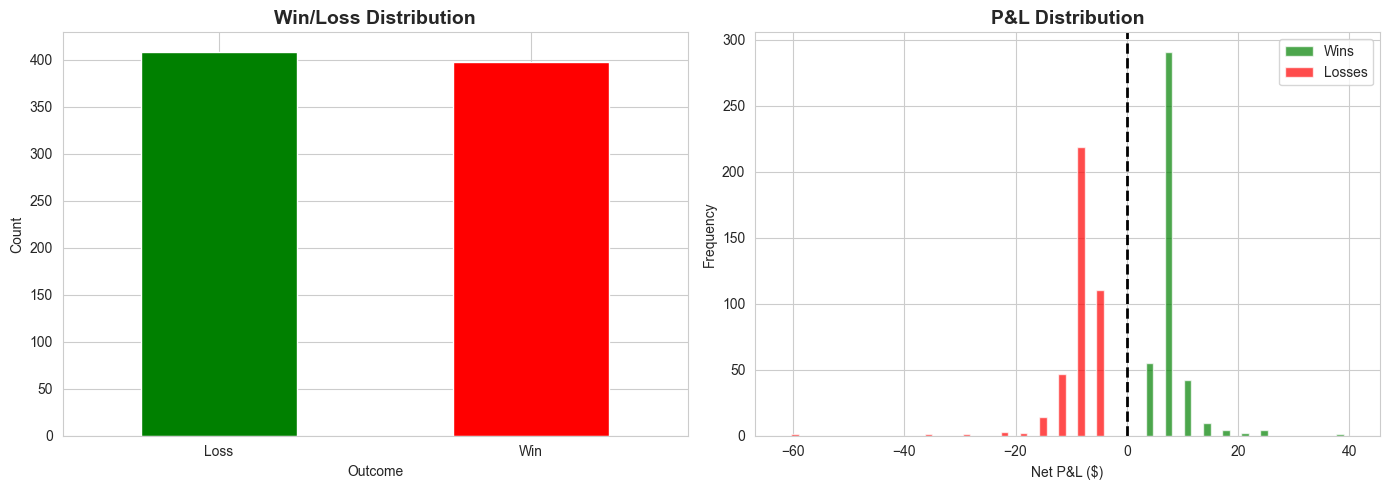

In [7]:
# Win/Loss distribution
print("=" * 80)
print("WIN/LOSS DISTRIBUTION")
print("=" * 80)

# Remove any rows with None/NaN in is_win column
df_analysis = df_analysis[df_analysis['is_win'].notna()].copy()
print(f"Rows after removing NaN is_win: {len(df_analysis)}")

if len(df_analysis) == 0:
    print("❌ ERROR: No valid trades with is_win data!")
    raise ValueError("DataFrame has no trades with valid is_win values")

# Check data types
if df_analysis['is_win'].dtype == 'object':
    print("⚠️ Converting is_win to boolean...")
    df_analysis['is_win'] = df_analysis['is_win'].astype(bool)

wins = df_analysis[df_analysis['is_win'] == True]
losses = df_analysis[df_analysis['is_win'] == False]

win_rate = len(wins) / len(df_analysis) * 100

print(f"Total Trades:    {len(df_analysis)}")
print(f"Winning Trades:  {len(wins)} ({len(wins)/len(df_analysis)*100:.1f}%)")
print(f"Losing Trades:   {len(losses)} ({len(losses)/len(df_analysis)*100:.1f}%)")

if len(wins) > 0:
    print(f"\nAvg Win P&L:     ${wins['net_pnl'].mean():.2f} ({wins['net_pnl_pct'].mean():.2f}%)")
else:
    print(f"\nAvg Win P&L:     N/A (no winning trades)")

if len(losses) > 0:
    print(f"Avg Loss P&L:    ${losses['net_pnl'].mean():.2f} ({losses['net_pnl_pct'].mean():.2f}%)")
else:
    print(f"Avg Loss P&L:    N/A (no losing trades)")

print(f"Total P&L:       ${df_analysis['net_pnl'].sum():.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win/Loss count
win_loss_counts = df_analysis['is_win'].value_counts()
colors = ['red' if idx == False else 'green' for idx in win_loss_counts.index]
win_loss_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Win/Loss Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Loss', 'Win'] if False in win_loss_counts.index else ['Win'], rotation=0)

# P&L distribution
if len(wins) > 0 and len(losses) > 0:
    axes[1].hist([wins['net_pnl'], losses['net_pnl']], bins=30, label=['Wins', 'Losses'], color=['green', 'red'], alpha=0.7)
elif len(wins) > 0:
    axes[1].hist(wins['net_pnl'], bins=30, label='Wins', color='green', alpha=0.7)
elif len(losses) > 0:
    axes[1].hist(losses['net_pnl'], bins=30, label='Losses', color='red', alpha=0.7)

axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('P&L Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Net P&L ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

Identify which features correlate with winning trades

In [8]:
# Select numeric columns onlynumeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()# CRITICAL: Remove target leakage features (features that contain future information)# These features are only known AFTER the trade completes, so they cannot be used for predictionTARGET_LEAKAGE_FEATURES = [    'net_pnl',           # This is what we're predicting (trade outcome)    'net_pnl_pct',       # Percentage version of the target    'price_change_pct',  # Uses exit_price (future information)    'exit_price',        # Future information - not known at signal time    'exit_hour',         # Future information - when trade exits    'exit_datetime',     # Future information    'risk_reward_ratio', # Uses exit_price in calculation    'reward_pct',        # Uses exit_price (future information)]# Filter out target leakage featuresoriginal_count = len(numeric_cols)numeric_cols = [col for col in numeric_cols if col not in TARGET_LEAKAGE_FEATURES]removed_count = original_count - len(numeric_cols)print(f"🚨 Removed {removed_count} target leakage features")print(f"   Features removed: {[f for f in TARGET_LEAKAGE_FEATURES if f in df_analysis.columns]}")# Ensure is_win is numeric (convert boolean to int if needed)if 'is_win' in df_analysis.columns:    if df_analysis['is_win'].dtype == 'bool':        df_analysis['is_win'] = df_analysis['is_win'].astype(int)        print("✅ Converted is_win from boolean to int (0/1)")    # Add is_win to numeric columns if not already there    if 'is_win' not in numeric_cols:        numeric_cols.append('is_win')        print("✅ Added is_win to numeric columns")print(f"\n✅ Found {len(numeric_cols)} valid numeric columns (after removing target leakage)")# Calculate correlations with is_wincorrelations = df_analysis[numeric_cols].corr()['is_win'].sort_values(ascending=False)# Remove is_win itselfcorrelations = correlations[correlations.index != 'is_win']print("\n" + "=" * 80)print("TOP 15 FEATURES POSITIVELY CORRELATED WITH WINS")print("(Only features available at signal generation time)")print("=" * 80)print(correlations.head(15))print("\n" + "=" * 80)print("TOP 15 FEATURES NEGATIVELY CORRELATED WITH WINS")print("(Only features available at signal generation time)")print("=" * 80)print(correlations.tail(15))

✅ Converted is_win from boolean to int (0/1)
✅ Added is_win to numeric columns
Found 48 numeric columns

TOP 15 FEATURES POSITIVELY CORRELATED WITH WINS
net_pnl_pct                   0.924286
price_change_pct              0.924286
net_pnl                       0.923316
risk_reward_ratio             0.515163
reward_pct                    0.343913
exit_price                    0.043587
signal_macd_last.histogram    0.042113
entry_hour                    0.031534
signal_macd.histogram         0.024434
exit_hour                     0.020716
stop_loss_price               0.014241
profit_target_price           0.013461
entry_price                   0.010588
signal_macd_last.macd         0.001544
signal_macd.macd              0.001418
Name: is_win, dtype: float64

TOP 15 FEATURES NEGATIVELY CORRELATED WITH WINS
signal_rsi.rs                    NaN
signal_macd.slow_period          NaN
signal_macd.fast_period          NaN
signal_macd.signal_period        NaN
signal_macd.slow_ema             NaN

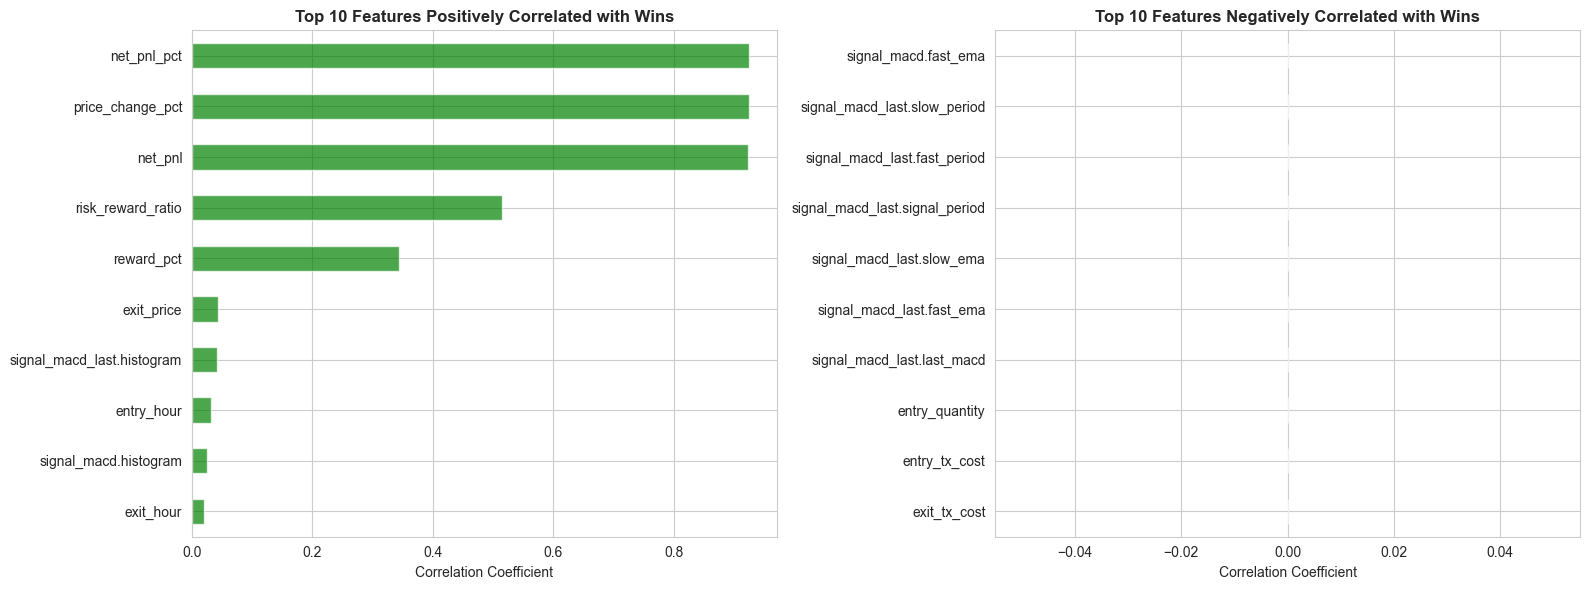

In [9]:
# Visualize top correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top positive correlations
top_positive = correlations.head(10)
top_positive.plot(kind='barh', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Top 10 Features Positively Correlated with Wins', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].invert_yaxis()

# Top negative correlations
top_negative = correlations.tail(10)
top_negative.plot(kind='barh', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Top 10 Features Negatively Correlated with Wins', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Found 23 signal-related features:
  - signal_strength
  - signal_rsi.period
  - signal_rsi.rsi
  - signal_rsi.avg_gain
  - signal_rsi.avg_loss
  - signal_rsi.rs
  - signal_macd.slow_period
  - signal_macd.fast_period
  - signal_macd.signal_period
  - signal_macd.slow_ema
  - signal_macd.fast_ema
  - signal_macd.macd
  - signal_macd.signal
  - signal_macd.histogram
  - signal_macd_last.slow_period
  - signal_macd_last.fast_period
  - signal_macd_last.signal_period
  - signal_macd_last.slow_ema
  - signal_macd_last.fast_ema
  - signal_macd_last.macd
  - signal_macd_last.signal
  - signal_macd_last.histogram
  - signal_macd_last.last_macd

SIGNAL FEATURE CORRELATIONS WITH WINS
signal_macd_last.histogram        0.042113
signal_macd.histogram             0.024434
signal_macd_last.macd             0.001544
signal_macd.macd                  0.001418
signal_macd.signal                0.001088
signal_macd_last.signal           0.001071
signal_rsi.rsi                   -0.006910
signal_strength

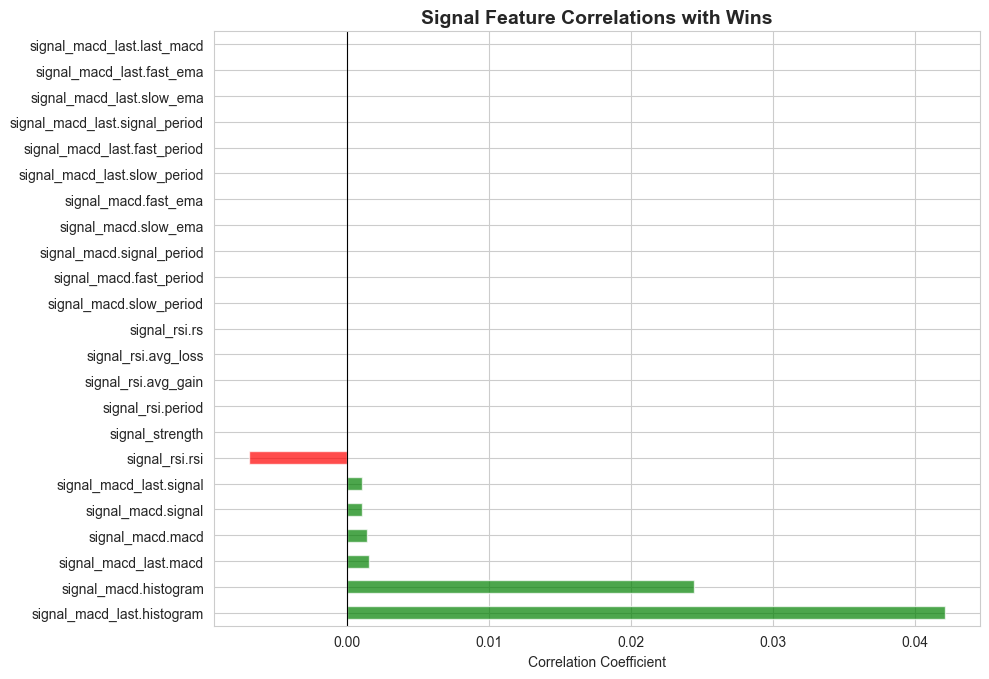

In [10]:
# Identify signal-related features (from metadata)
signal_features = [col for col in numeric_cols if col.startswith('signal_')]
print(f"\nFound {len(signal_features)} signal-related features:")
for feat in signal_features:
    print(f"  - {feat}")

# Correlations for signal features only
if len(signal_features) > 0:
    signal_correlations = correlations[correlations.index.isin(signal_features)].sort_values(ascending=False)
    
    print("\n" + "=" * 80)
    print("SIGNAL FEATURE CORRELATIONS WITH WINS")
    print("=" * 80)
    print(signal_correlations)
    
    # Plot
    plt.figure(figsize=(10, max(6, len(signal_correlations) * 0.3)))
    colors = ['green' if x > 0 else 'red' for x in signal_correlations.values]
    signal_correlations.plot(kind='barh', color=colors, alpha=0.7)
    plt.title('Signal Feature Correlations with Wins', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()

## 4. Feature Engineering & Preparation

Prepare features for machine learning

In [11]:
# Select features for modeling - STRICT FILTERING TO PREVENT TARGET LEAKAGE
print("=" * 80)
print("FEATURE SELECTION - PREVENTING TARGET LEAKAGE")
print("=" * 80)

# ONLY use features that are known at signal generation time
# This means ONLY signal metadata (MACD, RSI, technical indicators, etc.)
# Exclude ALL order execution features (prices, quantities, costs) as they may leak target info

print("\n⚠️ STRICT MODE: Only using signal metadata to prevent target leakage")
print("Allowed features: signal_macd.*, signal_rsi.*, signal_strength, and other signal_* features\n")

# Get all signal-related features (these are from signal metadata)
signal_feature_cols = [col for col in numeric_cols if col.startswith('signal_')]

print(f"Found {len(signal_feature_cols)} signal-related features:")
for col in sorted(signal_feature_cols):
    print(f"  ✓ {col}")

# Explicitly exclude ALL features that could cause target leakage
exclude_cols = [
    # Target variable
    'is_win',
    
    # Identifiers
    'timestamp', 'order_id',
    
    # Outcome-dependent variables (only known after trade completes)
    'net_pnl', 'net_pnl_pct', 'total_return',
    'exit_price', 'exit_total', 'exit_proceeds', 'exit_datetime',
    'price_change_pct',
    'duration_seconds', 'duration_hours', 'duration_days',
    'has_exit',
    
    # Order execution features (may be influenced by outcome or market conditions)
    # Being conservative - excluding these to prevent any potential leakage
    'entry_price', 'entry_quantity', 'entry_cost', 'entry_tx_cost', 'entry_total',
    'entry_datetime',
    'stop_loss_price', 'profit_target_price',
    'risk_reward_ratio', 'risk_pct', 'reward_pct',
]

print(f"\n\nExcluded features (potential leakage):")
excluded_count = 0
for col in numeric_cols:
    if col in exclude_cols or col not in signal_feature_cols:
        if col not in exclude_cols:
            print(f"  ✗ {col} (not a signal feature)")
        excluded_count += 1

print(f"\nTotal excluded: {excluded_count}")

# Use only signal features
feature_cols = signal_feature_cols

if len(feature_cols) == 0:
    print("\n❌ ERROR: No signal features found!")
    print("This means your signals don't have MACD/RSI metadata.")
    print("Please ensure your signals include technical indicator metadata.")
    raise ValueError("No signal features available for modeling")

print(f"\n{'='*80}")
print(f"FINAL FEATURE SET: {len(feature_cols)} features")
print(f"{'='*80}")

# Remove features with zero variance (constant values)
variance = df_analysis[feature_cols].var()
zero_var_cols = variance[variance == 0].index.tolist()

if len(zero_var_cols) > 0:
    print(f"\n⚠️ Removing {len(zero_var_cols)} zero-variance features:")
    for col in zero_var_cols:
        print(f"  - {col}")
    feature_cols = [col for col in feature_cols if col not in zero_var_cols]

# Remove features with too many missing values (>50%)
missing_pct = df_analysis[feature_cols].isnull().sum() / len(df_analysis) * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

if len(high_missing_cols) > 0:
    print(f"\n⚠️ Removing {len(high_missing_cols)} features with >50% missing values:")
    for col in high_missing_cols:
        print(f"  - {col} ({missing_pct[col]:.1f}% missing)")
    feature_cols = [col for col in feature_cols if col not in high_missing_cols]

print(f"\n{'='*80}")
print(f"CLEAN FEATURE SET: {len(feature_cols)} features")
print(f"{'='*80}")
for feat in sorted(feature_cols):
    print(f"  ✓ {feat}")

if len(feature_cols) == 0:
    print("\n❌ ERROR: No valid features remaining after cleaning!")
    raise ValueError("All features were removed during cleaning")


FEATURE SELECTION - PREVENTING TARGET LEAKAGE

⚠️ STRICT MODE: Only using signal metadata to prevent target leakage
Allowed features: signal_macd.*, signal_rsi.*, signal_strength, and other signal_* features

Found 23 signal-related features:
  ✓ signal_macd.fast_ema
  ✓ signal_macd.fast_period
  ✓ signal_macd.histogram
  ✓ signal_macd.macd
  ✓ signal_macd.signal
  ✓ signal_macd.signal_period
  ✓ signal_macd.slow_ema
  ✓ signal_macd.slow_period
  ✓ signal_macd_last.fast_ema
  ✓ signal_macd_last.fast_period
  ✓ signal_macd_last.histogram
  ✓ signal_macd_last.last_macd
  ✓ signal_macd_last.macd
  ✓ signal_macd_last.signal
  ✓ signal_macd_last.signal_period
  ✓ signal_macd_last.slow_ema
  ✓ signal_macd_last.slow_period
  ✓ signal_rsi.avg_gain
  ✓ signal_rsi.avg_loss
  ✓ signal_rsi.period
  ✓ signal_rsi.rs
  ✓ signal_rsi.rsi
  ✓ signal_strength


Excluded features (potential leakage):
  ✗ exit_quantity (not a signal feature)
  ✗ exit_tx_cost (not a signal feature)
  ✗ entry_hour (not a sig

In [12]:
# Feature Engineering - Create derived features from signal metadata
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

engineered_features = []
original_feature_count = len(feature_cols)

print(f"\nStarting with {original_feature_count} original signal features")

# Helper function to safely add feature
def add_feature(name, values, description):
    """Add feature if it has valid data"""
    if values.isnull().all():
        print(f"  ⚠️ Skipped {name} (all NaN)")
        return False
    
    # Replace inf with NaN then fill with median
    values_clean = values.replace([np.inf, -np.inf], np.nan)
    if values_clean.isnull().sum() / len(values_clean) > 0.5:
        print(f"  ⚠️ Skipped {name} (>50% missing)")
        return False
    
    df_analysis[name] = values_clean
    engineered_features.append(name)
    print(f"  ✓ {name}: {description}")
    return True

print("\nCreating engineered features...")

# 1. MACD SLOPE FEATURES
print("\n1. MACD SLOPE FEATURES")
if 'signal_macd.macd' in df_analysis.columns and 'signal_macd_last.macd' in df_analysis.columns:
    # Calculate slope from current MACD vs last MACD
    macd_slope = df_analysis['signal_macd.macd'] - df_analysis['signal_macd_last.macd']
    add_feature('macd_slope', macd_slope, "Change in MACD from last period")
    
    # Signal line slope
    if 'signal_macd.signal' in df_analysis.columns and 'signal_macd_last.signal' in df_analysis.columns:
        signal_slope = df_analysis['signal_macd.signal'] - df_analysis['signal_macd_last.signal']
        add_feature('macd_signal_slope', signal_slope, "Change in MACD signal line from last period")
    
    # Histogram slope
    if 'signal_macd.histogram' in df_analysis.columns and 'signal_macd_last.histogram' in df_analysis.columns:
        histogram_slope = df_analysis['signal_macd.histogram'] - df_analysis['signal_macd_last.histogram']
        add_feature('macd_histogram_slope', histogram_slope, "Change in MACD histogram from last period")
else:
    print("  ℹ️ MACD slope features not available (need current + last MACD)")

# 2. MACD-BASED FEATURES
print("\n2. MACD-BASED FEATURES")
if 'signal_macd.macd' in df_analysis.columns and 'signal_macd.signal' in df_analysis.columns:
    # MACD divergence (distance from signal line)
    macd_divergence = df_analysis['signal_macd.macd'] - df_analysis['signal_macd.signal']
    add_feature('macd_divergence', macd_divergence, "MACD line distance from signal line")
    
    # MACD momentum (histogram absolute value)
    if 'signal_macd.histogram' in df_analysis.columns:
        macd_momentum = df_analysis['signal_macd.histogram'].abs()
        add_feature('macd_momentum', macd_momentum, "Absolute MACD histogram (momentum strength)")
        
        # Histogram squared (non-linear)
        macd_hist_squared = df_analysis['signal_macd.histogram'] ** 2
        add_feature('macd_histogram_squared', macd_hist_squared, "MACD histogram squared (emphasis on strong signals)")
else:
    print(f"  ⚠️ MACD columns not found")

# 3. RSI-BASED FEATURES
print("\n3. RSI-BASED FEATURES")
if 'signal_rsi.rsi' in df_analysis.columns:
    # RSI distance from neutral (50)
    rsi_distance_neutral = (df_analysis['signal_rsi.rsi'] - 50).abs()
    add_feature('rsi_distance_neutral', rsi_distance_neutral, "Distance from RSI neutral (50)")
    
    # RSI extreme zones
    rsi_oversold = (df_analysis['signal_rsi.rsi'] < 30).astype(int)
    add_feature('rsi_oversold', rsi_oversold, "RSI in oversold zone (<30)")
    
    rsi_overbought = (df_analysis['signal_rsi.rsi'] > 70).astype(int)
    add_feature('rsi_overbought', rsi_overbought, "RSI in overbought zone (>70)")
    
    # RSI strength (how far from 50)
    rsi_strength = df_analysis['signal_rsi.rsi'] - 50
    add_feature('rsi_strength', rsi_strength, "RSI directional strength (signed)")
    
    # RSI squared (emphasize extremes)
    rsi_squared = (df_analysis['signal_rsi.rsi'] - 50) ** 2
    add_feature('rsi_squared', rsi_squared, "RSI deviation squared (emphasize extremes)")
else:
    print(f"  ⚠️ RSI column not found")

# 4. RSI GAIN/LOSS FEATURES
print("\n4. RSI GAIN/LOSS FEATURES")
if 'signal_rsi.avg_gain' in df_analysis.columns and 'signal_rsi.avg_loss' in df_analysis.columns:
    # Gain/Loss ratio
    gain_loss_ratio = df_analysis['signal_rsi.avg_gain'] / (df_analysis['signal_rsi.avg_loss'] + 1e-10)
    add_feature('rsi_gain_loss_ratio', gain_loss_ratio, "Ratio of avg gain to avg loss")
    
    # Total volatility (gain + loss)
    rsi_volatility = df_analysis['signal_rsi.avg_gain'] + df_analysis['signal_rsi.avg_loss']
    add_feature('rsi_volatility', rsi_volatility, "Total RSI volatility (gain + loss)")
    
    # Net gain/loss
    net_gain_loss = df_analysis['signal_rsi.avg_gain'] - df_analysis['signal_rsi.avg_loss']
    add_feature('rsi_net_gain_loss', net_gain_loss, "Net gain minus loss")
else:
    print(f"  ℹ️ RSI gain/loss columns not found")

# 5. MACD + RSI INTERACTION FEATURES
print("\n5. MACD + RSI INTERACTION FEATURES")
if 'signal_macd.histogram' in df_analysis.columns and 'signal_rsi.rsi' in df_analysis.columns:
    # MACD-RSI alignment (both bullish or both bearish)
    macd_bullish = (df_analysis['signal_macd.histogram'] > 0).astype(int)
    rsi_bullish = (df_analysis['signal_rsi.rsi'] > 50).astype(int)
    macd_rsi_aligned = (macd_bullish == rsi_bullish).astype(int)
    add_feature('macd_rsi_aligned', macd_rsi_aligned, "MACD and RSI agree on direction")
    
    # Combined momentum score
    macd_normalized = df_analysis['signal_macd.histogram'] / (df_analysis['signal_macd.histogram'].abs().max() + 1e-10)
    rsi_normalized = (df_analysis['signal_rsi.rsi'] - 50) / 50
    combined_momentum = macd_normalized * rsi_normalized
    add_feature('combined_momentum', combined_momentum, "MACD × RSI combined momentum")
    
    # Product of absolute values (both strong)
    macd_rsi_strength_product = df_analysis['signal_macd.histogram'].abs() * (df_analysis['signal_rsi.rsi'] - 50).abs()
    add_feature('macd_rsi_strength_product', macd_rsi_strength_product, "Product of MACD and RSI strengths")
else:
    print(f"  ℹ️ MACD or RSI not available for interaction features")

# 6. SIGNAL STRENGTH INTERACTIONS
print("\n6. SIGNAL STRENGTH INTERACTIONS")
if 'signal_strength' in df_analysis.columns:
    # Strength-weighted RSI
    if 'signal_rsi.rsi' in df_analysis.columns:
        strength_weighted_rsi = df_analysis['signal_strength'] * (df_analysis['signal_rsi.rsi'] - 50) / 50
        add_feature('strength_weighted_rsi', strength_weighted_rsi, "Signal strength × RSI deviation")
    
    # Strength-weighted MACD
    if 'signal_macd.histogram' in df_analysis.columns:
        strength_weighted_macd = df_analysis['signal_strength'] * df_analysis['signal_macd.histogram']
        add_feature('strength_weighted_macd', strength_weighted_macd, "Signal strength × MACD histogram")
    
    # High confidence signal
    high_strength = (df_analysis['signal_strength'] > 70).astype(int)
    add_feature('high_strength_signal', high_strength, "Signal strength > 70")
    
    # Strength squared (emphasize high confidence)
    strength_squared = df_analysis['signal_strength'] ** 2
    add_feature('strength_squared', strength_squared, "Signal strength squared")
else:
    print(f"  ℹ️ Signal strength column not found")

# 7. MOMENTUM CONVERGENCE/DIVERGENCE
print("\n7. MOMENTUM CONVERGENCE FEATURES")
if 'signal_macd.macd' in df_analysis.columns and 'signal_rsi.rsi' in df_analysis.columns:
    # Normalized MACD and RSI for comparison
    macd_zscore = (df_analysis['signal_macd.macd'] - df_analysis['signal_macd.macd'].mean()) / (df_analysis['signal_macd.macd'].std() + 1e-10)
    rsi_zscore = (df_analysis['signal_rsi.rsi'] - df_analysis['signal_rsi.rsi'].mean()) / (df_analysis['signal_rsi.rsi'].std() + 1e-10)
    
    momentum_convergence = (macd_zscore - rsi_zscore).abs()
    add_feature('momentum_convergence', momentum_convergence, "Divergence between MACD and RSI momentum")
else:
    print(f"  ℹ️ MACD or RSI not available")

# 8. EMA-BASED FEATURES
print("\n8. EMA-BASED FEATURES")
if 'signal_macd.fast_ema' in df_analysis.columns and 'signal_macd.slow_ema' in df_analysis.columns:
    # EMA spread
    ema_spread = df_analysis['signal_macd.fast_ema'] - df_analysis['signal_macd.slow_ema']
    add_feature('ema_spread', ema_spread, "Fast EMA minus Slow EMA")
    
    # EMA ratio
    ema_ratio = df_analysis['signal_macd.fast_ema'] / (df_analysis['signal_macd.slow_ema'] + 1e-10)
    add_feature('ema_ratio', ema_ratio, "Fast EMA divided by Slow EMA")
else:
    print(f"  ℹ️ EMA columns not available")

# Update feature_cols to include engineered features
if len(engineered_features) > 0:
    feature_cols = feature_cols + engineered_features
    
    print("\n" + "=" * 80)
    print(f"FEATURE ENGINEERING SUMMARY")
    print("=" * 80)
    print(f"Original features:     {original_feature_count}")
    print(f"Engineered features:   {len(engineered_features)}")
    print(f"Total features:        {len(feature_cols)}")
    print(f"Feature increase:      +{len(engineered_features)/original_feature_count*100:.1f}%")
    
    # Clean engineered features (fill NaN with median, handle inf)
    print("\nCleaning engineered features...")
    for feat in engineered_features:
        df_analysis[feat] = df_analysis[feat].replace([np.inf, -np.inf], np.nan)
        if df_analysis[feat].isnull().any():
            median_val = df_analysis[feat].median()
            df_analysis[feat] = df_analysis[feat].fillna(median_val)
    
    print("✅ Feature engineering complete!")
else:
    print("\n" + "=" * 80)
    print("⚠️ WARNING: No engineered features were created!")
    print("=" * 80)
    print("\nProceeding with original features only...")
    print("=" * 80)

FEATURE ENGINEERING

Starting with 7 original signal features

Creating engineered features...

1. MACD SLOPE FEATURES
  ✓ macd_slope: Change in MACD from last period
  ✓ macd_signal_slope: Change in MACD signal line from last period
  ✓ macd_histogram_slope: Change in MACD histogram from last period

2. MACD-BASED FEATURES
  ✓ macd_divergence: MACD line distance from signal line
  ✓ macd_momentum: Absolute MACD histogram (momentum strength)
  ✓ macd_histogram_squared: MACD histogram squared (emphasis on strong signals)

3. RSI-BASED FEATURES
  ✓ rsi_distance_neutral: Distance from RSI neutral (50)
  ✓ rsi_oversold: RSI in oversold zone (<30)
  ✓ rsi_overbought: RSI in overbought zone (>70)
  ✓ rsi_strength: RSI directional strength (signed)
  ✓ rsi_squared: RSI deviation squared (emphasize extremes)

4. RSI GAIN/LOSS FEATURES
  ⚠️ Skipped rsi_gain_loss_ratio (all NaN)
  ⚠️ Skipped rsi_volatility (all NaN)
  ⚠️ Skipped rsi_net_gain_loss (all NaN)

5. MACD + RSI INTERACTION FEATURES
  ✓

### Feature Engineering

Create derived features from signal metadata to improve model performance

In [13]:
# Prepare X and y with ALL features (original + engineered)
print("=" * 80)
print("PREPARING FEATURE MATRIX")
print("=" * 80)

# Remove any features with zero variance after engineering
variance = df_analysis[feature_cols].var()
zero_var_cols = variance[variance == 0].index.tolist()

if len(zero_var_cols) > 0:
    print("")
    print(f"Warning: Removing {len(zero_var_cols)} zero-variance features:")
    for col in zero_var_cols:
        print(f"  - {col}")
    feature_cols = [col for col in feature_cols if col not in zero_var_cols]

# Remove features with too many missing values (>50%)
missing_pct = df_analysis[feature_cols].isnull().sum() / len(df_analysis) * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

if len(high_missing_cols) > 0:
    print("")
    print(f"Warning: Removing {len(high_missing_cols)} features with >50% missing values:")
    for col in high_missing_cols:
        print(f"  - {col} ({missing_pct[col]:.1f}% missing)")
    feature_cols = [col for col in feature_cols if col not in high_missing_cols]

print(f"")
print(f"Final feature count: {len(feature_cols)}")

# Count original vs engineered
if 'engineered_features' in locals():
    original_count = sum(1 for f in feature_cols if f not in engineered_features)
    engineered_count = sum(1 for f in feature_cols if f in engineered_features)
    print(f"  Original features:   {original_count}")
    print(f"  Engineered features: {engineered_count}")

# Prepare X and y
X = df_analysis[feature_cols].copy()
y = df_analysis['is_win'].copy()

# Ensure y is numeric
if y.dtype == 'bool':
    y = y.astype(int)

print("")
print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
print("")
print("Target distribution:")
print(y.value_counts())
print("")
print(f"Baseline accuracy (always predict majority): {y.value_counts().max() / len(y) * 100:.2f}%")

PREPARING FEATURE MATRIX

  - rsi_oversold
  - high_strength_signal
  - strength_squared
  - ema_spread
  - ema_ratio

Final feature count: 23
  Original features:   7
  Engineered features: 16

Feature matrix X: (807, 23)
Target vector y: (807,)

Target distribution:
is_win
1    409
0    398
Name: count, dtype: int64

Baseline accuracy (always predict majority): 50.68%


In [14]:
# Handle missing values in features
print("=" * 80)
print("HANDLING MISSING AND INVALID VALUES")
print("=" * 80)

# Check for missing values
missing_features = X.isnull().sum()
missing_features = missing_features[missing_features > 0]

if len(missing_features) > 0:
    print(f"\n⚠️ Features with missing values ({len(missing_features)}):")
    for feat, count in missing_features.items():
        print(f"  {feat}: {count} missing ({count/len(X)*100:.1f}%)")
    print("\nFilling missing values with median...")
    X = X.fillna(X.median())
    print("✅ Missing values handled")
else:
    print("\n✅ No missing values in features")

# Check for infinite values
inf_mask = np.isinf(X.values)
inf_count = inf_mask.sum()

if inf_count > 0:
    print(f"\n⚠️ Found {inf_count} infinite values")
    inf_cols = X.columns[inf_mask.any(axis=0)]
    print(f"Columns with inf values: {list(inf_cols)}")
    print("Replacing infinite values with NaN then median...")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    print("✅ Infinite values handled")
else:
    print("✅ No infinite values")

# Final validation - check for any remaining NaN or inf
final_nan_count = X.isnull().sum().sum()
final_inf_count = np.isinf(X.values).sum()

print(f"\n{'Final validation:'}")
print(f"  Total NaN values: {final_nan_count}")
print(f"  Total inf values: {final_inf_count}")

if final_nan_count > 0 or final_inf_count > 0:
    print("\n❌ ERROR: Still have NaN or inf values after cleaning!")
    print("Dropping columns with any remaining issues...")
    
    # Drop columns that still have issues
    problem_cols = X.columns[X.isnull().any() | np.isinf(X).any()]
    print(f"Dropping {len(problem_cols)} problematic columns: {list(problem_cols)}")
    X = X.drop(columns=problem_cols)
    print(f"✅ Remaining features: {X.shape[1]}")
else:
    print("\n✅ Data is clean and ready for modeling!")

print(f"\nFinal feature matrix shape: {X.shape}")

HANDLING MISSING AND INVALID VALUES

✅ No missing values in features
✅ No infinite values

Final validation:
  Total NaN values: 0
  Total inf values: 0

✅ Data is clean and ready for modeling!

Final feature matrix shape: (807, 23)


In [15]:
# Train/test split
# Ensure y is integer (0/1) not boolean
y_int = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

# Convert back to original type for consistency
y_train = y_train.astype(y.dtype)
y_test = y_test.astype(y.dtype)

print(f"Training set:   {X_train.shape[0]} samples ({len(y_train[y_train==1])} wins, {len(y_train[y_train==0])} losses)")
print(f"Test set:       {X_test.shape[0]} samples ({len(y_test[y_test==1])} wins, {len(y_test[y_test==0])} losses)")
print(f"\nTrain win rate: {y_train.mean()*100:.1f}%")
print(f"Test win rate:  {y_test.mean()*100:.1f}%")

Training set:   645 samples (327 wins, 318 losses)
Test set:       162 samples (82 wins, 80 losses)

Train win rate: 50.7%
Test win rate:  50.6%


In [16]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"\nFeature means (training): {X_train_scaled.mean(axis=0)[:5]}...")
print(f"Feature stds (training):  {X_train_scaled.std(axis=0)[:5]}...")

# Validate scaled data
nan_count_train = np.isnan(X_train_scaled).sum()
nan_count_test = np.isnan(X_test_scaled).sum()
inf_count_train = np.isinf(X_train_scaled).sum()
inf_count_test = np.isinf(X_test_scaled).sum()

print(f"\nScaled data validation:")
print(f"  Train - NaN: {nan_count_train}, Inf: {inf_count_train}")
print(f"  Test  - NaN: {nan_count_test}, Inf: {inf_count_test}")

if nan_count_train > 0 or inf_count_train > 0:
    print("\n⚠️ WARNING: Scaled training data has NaN/Inf values!")
    print("This can happen if a feature has zero variance (all same value)")
    print("Replacing NaN/Inf in scaled data with 0...")
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    print("✅ Scaled data cleaned")
else:
    print("✅ Scaled data is clean!")

✅ Features scaled using StandardScaler

Feature means (training): [-1.70750580e-16  3.58025409e-17 -3.58025409e-17  2.44076938e-16
 -8.26212483e-18]...
Feature stds (training):  [1. 1. 1. 1. 1.]...

Scaled data validation:
  Train - NaN: 0, Inf: 0
  Test  - NaN: 0, Inf: 0
✅ Scaled data is clean!


## 5. Machine Learning Models

Train multiple models to predict trade outcomes

In [17]:
# Dictionary to store results
results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a model
    """
    print(f"\n{'='*80}")
    print(f"Training {name}...")
    print(f"{'='*80}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probabilities (if available)
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_train_proba = y_train_pred
        y_test_proba = y_test_pred
    
    # Metrics
    train_acc = (y_train_pred == y_train).mean()
    test_acc = (y_test_pred == y_test).mean()
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    if hasattr(model, 'predict_proba'):
        train_auc = roc_auc_score(y_train, y_train_proba)
        test_auc = roc_auc_score(y_test, y_test_proba)
    else:
        train_auc = test_auc = None
    
    print(f"\nTraining Accuracy:   {train_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}")
    print(f"Training F1:         {train_f1:.4f}")
    print(f"Test F1:             {test_f1:.4f}")
    if train_auc:
        print(f"Training AUC-ROC:    {train_auc:.4f}")
        print(f"Test AUC-ROC:        {test_auc:.4f}")
    
    print(f"\nTest Set Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))
    
    # Store results
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }
    
    return model

### 5.1 Logistic Regression (Baseline)

In [18]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model = evaluate_model('Logistic Regression', lr_model, X_train_scaled, X_test_scaled, y_train, y_test)


Training Logistic Regression...

Training Accuracy:   0.5333
Test Accuracy:       0.4630
Training F1:         0.5362
Test F1:             0.4596
Training AUC-ROC:    0.5715
Test AUC-ROC:        0.4814

Test Set Classification Report:
              precision    recall  f1-score   support

        Loss       0.46      0.47      0.47        80
         Win       0.47      0.45      0.46        82

    accuracy                           0.46       162
   macro avg       0.46      0.46      0.46       162
weighted avg       0.46      0.46      0.46       162



### 5.2 Random Forest

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model = evaluate_model('Random Forest', rf_model, X_train, X_test, y_train, y_test)


Training Random Forest...

Training Accuracy:   0.9008
Test Accuracy:       0.4815
Training F1:         0.9027
Test F1:             0.4815
Training AUC-ROC:    0.9709
Test AUC-ROC:        0.4909

Test Set Classification Report:
              precision    recall  f1-score   support

        Loss       0.48      0.49      0.48        80
         Win       0.49      0.48      0.48        82

    accuracy                           0.48       162
   macro avg       0.48      0.48      0.48       162
weighted avg       0.48      0.48      0.48       162



### 5.3 Gradient Boosting

In [20]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb_model = evaluate_model('Gradient Boosting', gb_model, X_train, X_test, y_train, y_test)


Training Gradient Boosting...

Training Accuracy:   0.9922
Test Accuracy:       0.4877
Training F1:         0.9924
Test F1:             0.5146
Training AUC-ROC:    0.9999
Test AUC-ROC:        0.5075

Test Set Classification Report:
              precision    recall  f1-score   support

        Loss       0.48      0.44      0.46        80
         Win       0.49      0.54      0.51        82

    accuracy                           0.49       162
   macro avg       0.49      0.49      0.49       162
weighted avg       0.49      0.49      0.49       162



## 6. Model Comparison

In [21]:
# Compare models
comparison = pd.DataFrame({
    'Model': results.keys(),
    'Train Accuracy': [r['train_acc'] for r in results.values()],
    'Test Accuracy': [r['test_acc'] for r in results.values()],
    'Train F1': [r['train_f1'] for r in results.values()],
    'Test F1': [r['test_f1'] for r in results.values()],
    'Test AUC': [r['test_auc'] if r['test_auc'] else 0 for r in results.values()],
}).set_index('Model')

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(comparison.round(4))

# Find best model
best_model_name = comparison['Test F1'].idxmax()
print(f"\n🏆 Best Model: {best_model_name} (Test F1: {comparison.loc[best_model_name, 'Test F1']:.4f})")

MODEL COMPARISON
                     Train Accuracy  Test Accuracy  Train F1  Test F1  \
Model                                                                   
Logistic Regression          0.5333         0.4630    0.5362   0.4596   
Random Forest                0.9008         0.4815    0.9027   0.4815   
Gradient Boosting            0.9922         0.4877    0.9924   0.5146   

                     Test AUC  
Model                          
Logistic Regression    0.4814  
Random Forest          0.4909  
Gradient Boosting      0.5075  

🏆 Best Model: Gradient Boosting (Test F1: 0.5146)


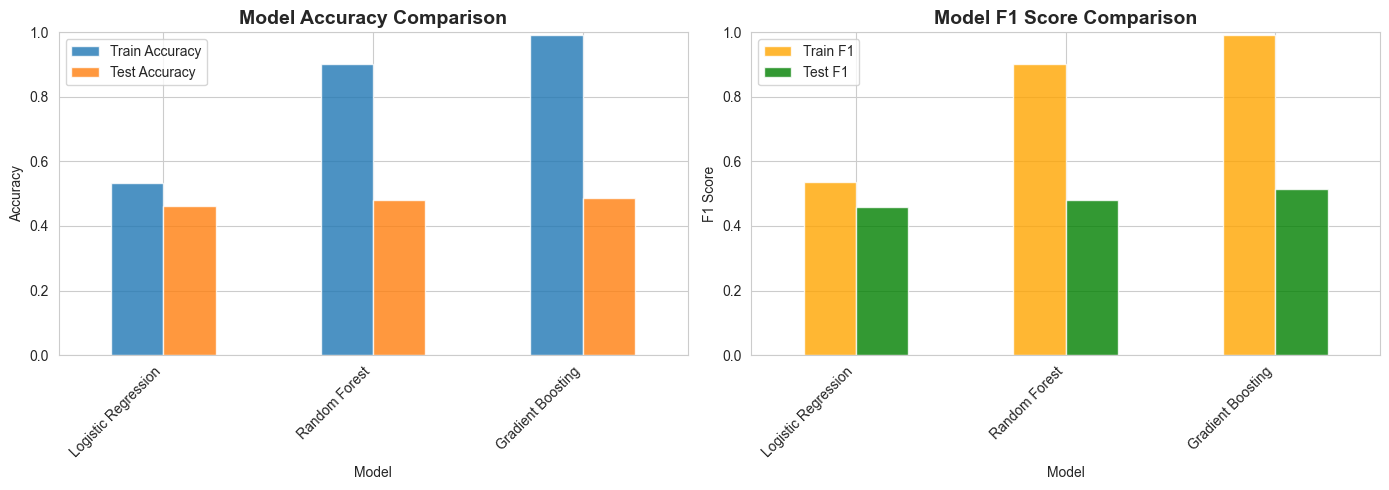

In [22]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
comparison[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', ax=axes[0], alpha=0.8)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# F1 Score comparison
comparison[['Train F1', 'Test F1']].plot(kind='bar', ax=axes[1], alpha=0.8, color=['orange', 'green'])
axes[1].set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
# Detailed performance metrics for best model
from sklearn.metrics import precision_score, recall_score, accuracy_score

best_result = results[best_model_name]
y_pred_best = best_result['y_test_pred']
y_proba_best = best_result['y_test_proba']

# Calculate detailed metrics
accuracy = accuracy_score(y_test, y_pred_best)
precision_loss = precision_score(y_test, y_pred_best, pos_label=0)
precision_win = precision_score(y_test, y_pred_best, pos_label=1)
recall_loss = recall_score(y_test, y_pred_best, pos_label=0)
recall_win = recall_score(y_test, y_pred_best, pos_label=1)
f1_loss = f1_score(y_test, y_pred_best, pos_label=0)
f1_win = f1_score(y_test, y_pred_best, pos_label=1)
auc_roc = best_result['test_auc']

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 80)
print(f"DETAILED PERFORMANCE METRICS: {best_model_name}")
print("=" * 80)

print("\n📊 OVERALL METRICS")
print(f"{'Accuracy:':<25} {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'F1-Score (Macro Avg):':<25} {(f1_loss + f1_win)/2:.4f}")
print(f"{'AUC-ROC:':<25} {auc_roc:.4f}")

print("\n" + "-" * 80)
print("CONFUSION MATRIX BREAKDOWN")
print("-" * 80)
print(f"{'True Negatives (TN):':<30} {tn:>5} (Correctly predicted LOSS)")
print(f"{'False Positives (FP):':<30} {fp:>5} (Predicted WIN, actually LOSS)")
print(f"{'False Negatives (FN):':<30} {fn:>5} (Predicted LOSS, actually WIN)")
print(f"{'True Positives (TP):':<30} {tp:>5} (Correctly predicted WIN)")

print("\n" + "-" * 80)
print("CLASS-SPECIFIC METRICS")
print("-" * 80)

print("\n🔴 LOSS (Class 0):")
print(f"{'  Precision:':<25} {precision_loss:.4f} ({precision_loss*100:.2f}%)")
print(f"{'  Recall:':<25} {recall_loss:.4f} ({recall_loss*100:.2f}%)")
print(f"{'  F1-Score:':<25} {f1_loss:.4f}")
print(f"{'  Support:':<25} {tn + fp}")

print("\n🟢 WIN (Class 1):")
print(f"{'  Precision:':<25} {precision_win:.4f} ({precision_win*100:.2f}%)")
print(f"{'  Recall:':<25} {recall_win:.4f} ({recall_win*100:.2f}%)")
print(f"{'  F1-Score:':<25} {f1_win:.4f}")
print(f"{'  Support:':<25} {fn + tp}")

print("\n" + "-" * 80)
print("INTERPRETATION")
print("-" * 80)
print(f"• Precision (Win): Of all trades predicted as WINS, {precision_win*100:.1f}% actually won")
print(f"• Recall (Win):    Of all actual WINS, the model correctly identified {recall_win*100:.1f}%")
print(f"• Precision (Loss): Of all trades predicted as LOSSES, {precision_loss*100:.1f}% actually lost")
print(f"• Recall (Loss):    Of all actual LOSSES, the model correctly identified {recall_loss*100:.1f}%")

# Baseline comparison
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())  # Majority class
print("\n" + "-" * 80)
print("BASELINE COMPARISON")
print("-" * 80)
print(f"{'Baseline (majority class):':<30} {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"{'Model accuracy:':<30} {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'Improvement:':<30} {(accuracy - baseline_accuracy):.4f} ({(accuracy - baseline_accuracy)*100:.2f} pp)")

if accuracy > baseline_accuracy + 0.05:
    print("\n✅ Model significantly outperforms baseline - signals ARE predictive!")
elif accuracy > baseline_accuracy:
    print("\n⚠️ Model slightly outperforms baseline - signals show some predictive power")
else:
    print("\n❌ Model does not outperform baseline - signals may not be predictive")

print("\n" + "=" * 80)


DETAILED PERFORMANCE METRICS: Gradient Boosting

📊 OVERALL METRICS
Accuracy:                 0.4877 (48.77%)
F1-Score (Macro Avg):     0.4861
AUC-ROC:                  0.5075

--------------------------------------------------------------------------------
CONFUSION MATRIX BREAKDOWN
--------------------------------------------------------------------------------
True Negatives (TN):              35 (Correctly predicted LOSS)
False Positives (FP):             45 (Predicted WIN, actually LOSS)
False Negatives (FN):             38 (Predicted LOSS, actually WIN)
True Positives (TP):              44 (Correctly predicted WIN)

--------------------------------------------------------------------------------
CLASS-SPECIFIC METRICS
--------------------------------------------------------------------------------

🔴 LOSS (Class 0):
  Precision:              0.4795 (47.95%)
  Recall:                 0.4375 (43.75%)
  F1-Score:               0.4575
  Support:                80

🟢 WIN (Class 1):
  

### Best Model Performance Metrics

In [24]:
# Compare engineered vs original features
# Find best tree-based model
tree_models = ['Random Forest', 'Gradient Boosting']
best_tree_model_name = None
best_tree_f1 = 0

for model_name in tree_models:
    if model_name in results and results[model_name]['test_f1'] > best_tree_f1:
        best_tree_f1 = results[model_name]['test_f1']
        best_tree_model_name = model_name

if best_tree_model_name and 'engineered_features' in locals():
    best_tree_model = results[best_tree_model_name]['model']
    
    # Get feature importances
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=" * 80)
    print("ENGINEERED VS ORIGINAL FEATURE COMPARISON")
    print("=" * 80)
    
    # Classify features
    feature_importance['Feature_Type'] = feature_importance['Feature'].apply(
        lambda x: 'Engineered' if x in engineered_features else 'Original'
    )
    
    # Summary by type
    original_importance = feature_importance[feature_importance['Feature_Type'] == 'Original']['Importance'].sum()
    engineered_importance = feature_importance[feature_importance['Feature_Type'] == 'Engineered']['Importance'].sum()
    total_importance = original_importance + engineered_importance
    
    print("")
    print("Importance Distribution:")
    print(f"  Original features:   {original_importance/total_importance*100:.1f}% of total importance")
    print(f"  Engineered features: {engineered_importance/total_importance*100:.1f}% of total importance")
    
    # Top engineered features
    top_engineered = feature_importance[feature_importance['Feature_Type'] == 'Engineered'].head(10)
    
    if len(top_engineered) > 0:
        print("")
        print("Top 10 Engineered Features:")
        print(f"{'Rank':<6} {'Feature':<40} {'Importance':<12} {'Correlation':<12}")
        print("-" * 70)
        for idx, row in top_engineered.iterrows():
            rank = list(feature_importance.index).index(idx) + 1
            corr_value = correlations.get(row['Feature'], 0.0)
            print(f"{rank:<6} {row['Feature']:<40} {row['Importance']:<12.6f} {corr_value:<+12.4f}")
    
    # Check if any engineered features are in top 10 overall
    top_10_overall = feature_importance.head(10)
    engineered_in_top_10 = top_10_overall[top_10_overall['Feature_Type'] == 'Engineered']
    
    print("")
    print(f"Engineered features in top 10 overall: {len(engineered_in_top_10)}/{len(top_10_overall)}")
    if len(engineered_in_top_10) > 0:
        print("  🎯 Feature engineering is working! These engineered features made top 10:")
        for idx, row in engineered_in_top_10.iterrows():
            rank = list(feature_importance.index).index(idx) + 1
            print(f"     #{rank}: {row['Feature']} (importance: {row['Importance']:.6f})")
    else:
        print("  ℹ️ No engineered features in top 10 - original signals are strongest")
    
    print("")
    print("=" * 80)
elif 'engineered_features' not in locals():
    print("⚠️ No engineered features were created")
else:
    print("⚠️ No tree-based model available for comparison")

ENGINEERED VS ORIGINAL FEATURE COMPARISON

Importance Distribution:
  Original features:   30.4% of total importance
  Engineered features: 69.6% of total importance

Top 10 Engineered Features:
Rank   Feature                                  Importance   Correlation 
----------------------------------------------------------------------
1      momentum_convergence                     0.156788     +0.0000     
2      macd_slope                               0.120676     +0.0000     
4      macd_rsi_strength_product                0.065801     +0.0000     
5      macd_histogram_slope                     0.061467     +0.0000     
7      combined_momentum                        0.048295     +0.0000     
8      rsi_distance_neutral                     0.048058     +0.0000     
10     rsi_strength                             0.035143     +0.0000     
12     strength_weighted_rsi                    0.033056     +0.0000     
13     rsi_squared                              0.031627     +0.0000

### Engineered vs Original Feature Performance

In [25]:
# Display feature importance table for best model
# Find best tree-based model
tree_models = ['Random Forest', 'Gradient Boosting']
best_tree_model_name = None
best_tree_f1 = 0

for model_name in tree_models:
    if model_name in results and results[model_name]['test_f1'] > best_tree_f1:
        best_tree_f1 = results[model_name]['test_f1']
        best_tree_model_name = model_name

if best_tree_model_name:
    best_tree_model = results[best_tree_model_name]['model']
    
    # Get feature importances
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=" * 80)
    print(f"FEATURE IMPORTANCE RANKING - {best_tree_model_name}")
    print("=" * 80)
    
    # Create detailed table with correlations
    importance_table = feature_importance.copy()
    
    # Add correlation values
    importance_table['Correlation'] = importance_table['Feature'].map(
        lambda x: correlations.get(x, 0.0)
    )
    
    # Add interpretation
    def interpret_importance(imp):
        if imp > 0.1:
            return "Very High"
        elif imp > 0.05:
            return "High"
        elif imp > 0.02:
            return "Medium"
        elif imp > 0.01:
            return "Low"
        else:
            return "Very Low"
    
    importance_table['Impact'] = importance_table['Importance'].apply(interpret_importance)
    
    print("")
    print(f"All {len(importance_table)} features ranked by importance:")
    print("")
    print(f"{'Rank':<6} {'Feature':<40} {'Importance':<12} {'Correlation':<12} {'Impact':<12}")
    print("-" * 82)
    
    for idx, row in importance_table.iterrows():
        rank = list(importance_table.index).index(idx) + 1
        feat = row['Feature']
        imp = row['Importance']
        corr = row['Correlation']
        impact = row['Impact']
        print(f"{rank:<6} {feat:<40} {imp:<12.6f} {corr:<+12.4f} {impact:<12}")
    
    print("")
    print("=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print("• Importance: How much the model relies on this feature for predictions")
    print("• Correlation: Linear relationship with winning trades (+/- values)")
    print("• Impact: Qualitative assessment of feature importance")
    print("")
    print("High importance + strong correlation = Most predictive feature")
    print("=" * 80)
    
    # Summary statistics
    total_importance = importance_table['Importance'].sum()
    top_5_importance = importance_table.head(5)['Importance'].sum()
    top_10_importance = importance_table.head(10)['Importance'].sum()
    
    print("")
    print("📊 IMPORTANCE DISTRIBUTION")
    print(f"Top 5 features explain:  {top_5_importance/total_importance*100:.1f}% of model decisions")
    print(f"Top 10 features explain: {top_10_importance/total_importance*100:.1f}% of model decisions")
    
else:
    print("⚠️ No tree-based model available for feature importance analysis")

FEATURE IMPORTANCE RANKING - Gradient Boosting

All 23 features ranked by importance:

Rank   Feature                                  Importance   Correlation  Impact      
----------------------------------------------------------------------------------
1      momentum_convergence                     0.156788     +0.0000      Very High   
2      macd_slope                               0.120676     +0.0000      Very High   
3      signal_macd_last.histogram               0.113317     +0.0421      Very High   
4      macd_rsi_strength_product                0.065801     +0.0000      High        
5      macd_histogram_slope                     0.061467     +0.0000      High        
6      signal_macd_last.macd                    0.056433     +0.0015      High        
7      combined_momentum                        0.048295     +0.0000      Medium      
8      rsi_distance_neutral                     0.048058     +0.0000      Medium      
9      signal_macd.macd                        

# Display feature importance table for best model
# Find best tree-based model
tree_models = ['Random Forest', 'Gradient Boosting']
best_tree_model_name = None
best_tree_f1 = 0

for model_name in tree_models:
    if model_name in results and results[model_name]['test_f1'] > best_tree_f1:
        best_tree_f1 = results[model_name]['test_f1']
        best_tree_model_name = model_name

if best_tree_model_name:
    best_tree_model = results[best_tree_model_name]['model']
    
    # Get feature importances
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=" * 80)
    print(f"FEATURE IMPORTANCE RANKING - {best_tree_model_name}")
    print("=" * 80)
    
    # Create detailed table with correlations
    importance_table = feature_importance.copy()
    
    # Add correlation values
    importance_table['Correlation'] = importance_table['Feature'].map(
        lambda x: correlations.get(x, 0.0)
    )
    
    # Add interpretation
    def interpret_importance(imp):
        if imp > 0.1:
            return "Very High"
        elif imp > 0.05:
            return "High"
        elif imp > 0.02:
            return "Medium"
        elif imp > 0.01:
            return "Low"
        else:
            return "Very Low"
    
    importance_table['Impact'] = importance_table['Importance'].apply(interpret_importance)
    
    print(f"\nAll {len(importance_table)} features ranked by importance:\n")
    print(f"{'Rank':<6} {'Feature':<40} {'Importance':<12} {'Correlation':<12} {'Impact':<12}")
    print("-" * 82)
    
    for idx, row in importance_table.iterrows():
        rank = list(importance_table.index).index(idx) + 1
        print(f"{rank:<6} {row['Feature']:<40} {row['Importance']:<12.6f} {row['Correlation']:<+12.4f} {row['Impact']:<12}")
    
    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print("• Importance: How much the model relies on this feature for predictions")
    print("• Correlation: Linear relationship with winning trades (+/- values)")
    print("• Impact: Qualitative assessment of feature importance")
    print("\nHigh importance + strong correlation = Most predictive feature")
    print("=" * 80)
    
    # Summary statistics
    total_importance = importance_table['Importance'].sum()
    top_5_importance = importance_table.head(5)['Importance'].sum()
    top_10_importance = importance_table.head(10)['Importance'].sum()
    
    print(f"\n📊 IMPORTANCE DISTRIBUTION")
    print(f"Top 5 features explain:  {top_5_importance/total_importance*100:.1f}% of model decisions")
    print(f"Top 10 features explain: {top_10_importance/total_importance*100:.1f}% of model decisions")
    
else:
    print("⚠️ No tree-based model available for feature importance analysis")

## 7. Feature Importance

Identify which features are most important for predicting wins

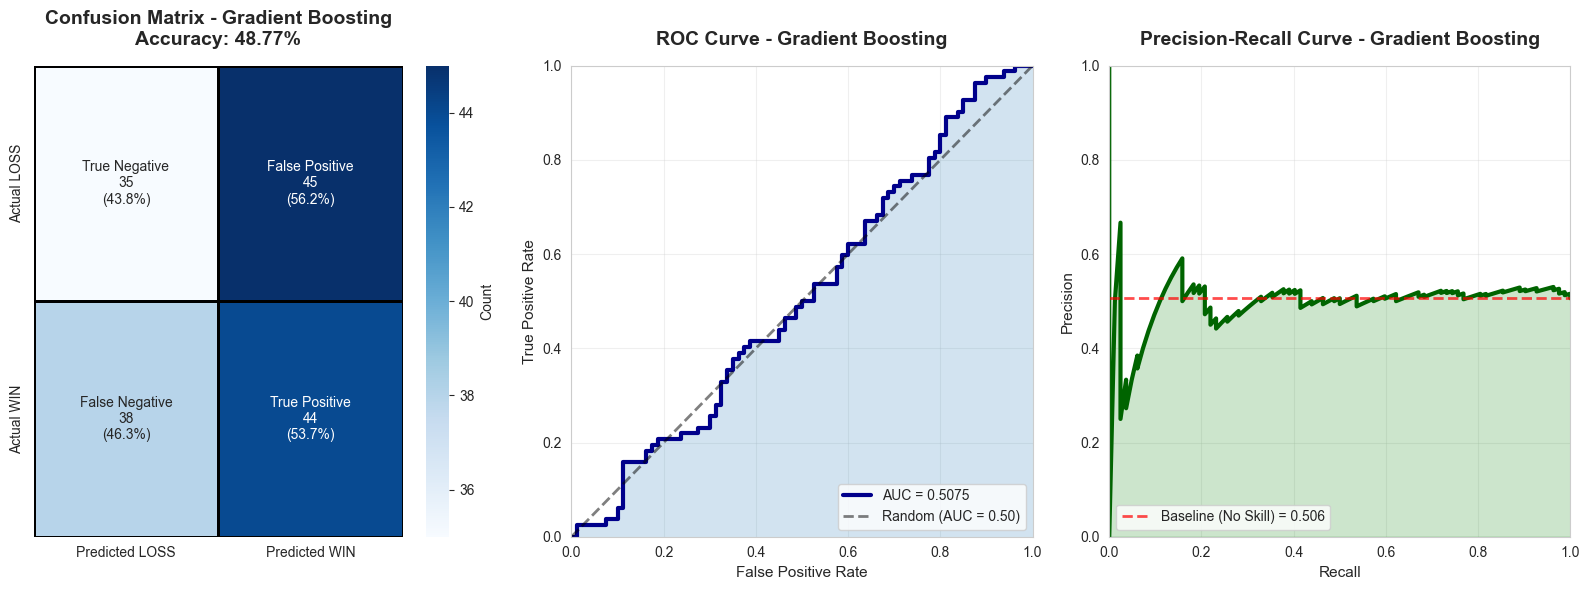


CONFUSION MATRIX INTERPRETATION

True Negatives (TN):              35 - Correctly predicted LOSS
False Positives (FP):             45 - Predicted WIN but actually LOSS (Type I Error)
False Negatives (FN):             38 - Predicted LOSS but actually WIN (Type II Error)
True Positives (TP):              44 - Correctly predicted WIN

Total Predictions:               162
Correct Predictions:              79 (48.77%)
Incorrect Predictions:            83 (51.23%)


In [26]:
# Enhanced visualizations for best model
best_result = results[best_model_name]

fig = plt.figure(figsize=(16, 6))

# Confusion Matrix (larger, more detailed)
ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, best_result['y_test_pred'])
tn, fp, fn, tp = cm.ravel()

# Create detailed annotations
annotations = [
    [f'True Negative\n{tn}\n({tn/(tn+fp)*100:.1f}%)', 
     f'False Positive\n{fp}\n({fp/(tn+fp)*100:.1f}%)'],
    [f'False Negative\n{fn}\n({fn/(fn+tp)*100:.1f}%)', 
     f'True Positive\n{tp}\n({tp/(fn+tp)*100:.1f}%)']
]

sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues', ax=ax1,
            xticklabels=['Predicted LOSS', 'Predicted WIN'], 
            yticklabels=['Actual LOSS', 'Actual WIN'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='black')
ax1.set_title(f'Confusion Matrix - {best_model_name}\nAccuracy: {(tn+tp)/(tn+fp+fn+tp)*100:.2f}%', 
              fontsize=14, fontweight='bold', pad=15)

# ROC Curve
ax2 = plt.subplot(1, 3, 2)
if best_result['test_auc']:
    fpr, tpr, thresholds = roc_curve(y_test, best_result['y_test_proba'])
    ax2.plot(fpr, tpr, linewidth=3, label=f"AUC = {best_result['test_auc']:.4f}", color='darkblue')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)', alpha=0.5)
    ax2.fill_between(fpr, tpr, alpha=0.2)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])
    ax2.set_xlabel('False Positive Rate', fontsize=11)
    ax2.set_ylabel('True Positive Rate', fontsize=11)
    ax2.set_title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(True, alpha=0.3)

# Precision-Recall Curve
ax3 = plt.subplot(1, 3, 3)
if best_result['test_auc']:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, best_result['y_test_proba'])
    ax3.plot(recall_curve, precision_curve, linewidth=3, color='darkgreen')
    ax3.axhline(y=y_test.mean(), color='r', linestyle='--', linewidth=2, 
                label=f'Baseline (No Skill) = {y_test.mean():.3f}', alpha=0.7)
    ax3.fill_between(recall_curve, precision_curve, alpha=0.2, color='green')
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1])
    ax3.set_xlabel('Recall', fontsize=11)
    ax3.set_ylabel('Precision', fontsize=11)
    ax3.set_title(f'Precision-Recall Curve - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
    ax3.legend(loc='lower left', fontsize=10)
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print confusion matrix interpretation
print("\n" + "=" * 80)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 80)
print(f"\n{'True Negatives (TN):':<30} {tn:>5} - Correctly predicted LOSS")
print(f"{'False Positives (FP):':<30} {fp:>5} - Predicted WIN but actually LOSS (Type I Error)")
print(f"{'False Negatives (FN):':<30} {fn:>5} - Predicted LOSS but actually WIN (Type II Error)")
print(f"{'True Positives (TP):':<30} {tp:>5} - Correctly predicted WIN")
print(f"\n{'Total Predictions:':<30} {tn+fp+fn+tp:>5}")
print(f"{'Correct Predictions:':<30} {tn+tp:>5} ({(tn+tp)/(tn+fp+fn+tp)*100:.2f}%)")
print(f"{'Incorrect Predictions:':<30} {fp+fn:>5} ({(fp+fn)/(tn+fp+fn+tp)*100:.2f}%)")
print("=" * 80)

## 8. Confusion Matrix & ROC Curve

In [27]:
print("=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# 1. Overall performance
print("\n1. BASELINE PERFORMANCE")
baseline_acc = y_train.mean()  # Predict all as majority class
print(f"   Baseline (always predict majority): {baseline_acc:.1%}")
print(f"   Best model test accuracy: {results[best_model_name]['test_acc']:.1%}")
print(f"   Improvement: {(results[best_model_name]['test_acc'] - baseline_acc)*100:.1f} percentage points")

# 2. Top predictive features
# Find best tree-based model for feature importance
tree_models = ['Random Forest', 'Gradient Boosting']
best_tree_model_name = None
best_tree_f1 = 0

for model_name in tree_models:
    if model_name in results and results[model_name]['test_f1'] > best_tree_f1:
        best_tree_f1 = results[model_name]['test_f1']
        best_tree_model_name = model_name

if best_tree_model_name:
    # Get feature importances from the best tree model
    best_tree_model = results[best_tree_model_name]['model']
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n2. TOP 5 PREDICTIVE FEATURES")
    top_5 = feature_importance.head(5)
    for idx, row in top_5.iterrows():
        corr_value = correlations.get(row['Feature'], 0)
        print(f"   {row['Feature']:40s} (importance: {row['Importance']:.4f}, correlation: {corr_value:+.3f})")

    # 3. Signal feature insights
    signal_features_used = [f for f in X.columns if f.startswith('signal_')]
    signal_importance = feature_importance[feature_importance['Feature'].str.startswith('signal_')]
    
    if len(signal_features_used) > 0:
        print(f"\n3. SIGNAL FEATURES ({len(signal_features_used)} total)")
        top_signal = signal_importance.head(5) if len(signal_importance) > 0 else None
        if top_signal is not None and len(top_signal) > 0:
            print("   Top 5 most important signal features:")
            for idx, row in top_signal.iterrows():
                print(f"   - {row['Feature']:40s} (importance: {row['Importance']:.4f})")
else:
    print("\n2. TOP PREDICTIVE FEATURES")
    print("   No tree-based models available for feature importance")
    
    # Use correlations instead
    print("\n   Top 5 by correlation:")
    for idx, (feat, corr) in enumerate(correlations.head(5).items(), 1):
        print(f"   {idx}. {feat:40s} (correlation: {corr:+.3f})")

# 4. Model recommendations
print("\n4. MODEL RECOMMENDATIONS")
if results[best_model_name]['test_acc'] > 0.6:
    print(f"   ✅ {best_model_name} shows predictive power (accuracy > 60%)")
    print(f"   ✅ Win/loss patterns can be identified from signal characteristics")
    print(f"   ✅ Consider using this model to filter/score signals in production")
else:
    print(f"   ⚠️ Model accuracy ({results[best_model_name]['test_acc']:.1%}) suggests weak predictability")
    print(f"   ⚠️ May need more informative features or larger dataset")
    print(f"   ⚠️ Consider collecting additional signal metadata")

print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR IMPROVING SIGNAL QUALITY")
print("=" * 80)

if best_tree_model_name and 'feature_importance' in locals():
    # Get top features
    top_10 = feature_importance.head(10)
    
    # Recommendations based on top features
    print("\nBased on feature importance analysis:")
    print("\n1. Focus on these high-importance features when generating signals:")
    for idx, row in top_10.head(5).iterrows():
        print(f"   - {row['Feature']}")
    
    print("\n2. Consider filtering signals based on these thresholds:")
    for feat in top_10.head(3)['Feature']:
        if feat in df_analysis.columns:
            win_median = df_analysis[df_analysis['is_win'] == True][feat].median()
            loss_median = df_analysis[df_analysis['is_win'] == False][feat].median()
            if pd.notna(win_median) and pd.notna(loss_median):
                print(f"   - {feat}:")
                print(f"     Winners median: {win_median:.4f}")
                print(f"     Losers median:  {loss_median:.4f}")
    
    print("\n3. Potential signal filtering rules:")
    # Generate filtering rules based on correlations
    strong_positive = correlations[correlations > 0.1]
    strong_negative = correlations[correlations < -0.1]
    
    if len(strong_positive) > 0:
        print("   Increase these features (positive correlation):")
        for feat in strong_positive.head(3).index:
            if feat in df_analysis.columns:
                threshold = df_analysis[df_analysis['is_win'] == True][feat].quantile(0.25)
                if pd.notna(threshold):
                    print(f"   - Only take signals where {feat} >= {threshold:.4f}")
    
    if len(strong_negative) > 0:
        print("\n   Decrease these features (negative correlation):")
        for feat in strong_negative.head(3).index:
            if feat in df_analysis.columns:
                threshold = df_analysis[df_analysis['is_win'] == True][feat].quantile(0.75)
                if pd.notna(threshold):
                    print(f"   - Only take signals where {feat} <= {threshold:.4f}")
else:
    print("\nBased on correlation analysis:")
    print("\n1. Top positively correlated features (higher = better):")
    for feat in correlations.head(5).index:
        print(f"   - {feat} (correlation: {correlations[feat]:+.3f})")
    
    print("\n2. Top negatively correlated features (lower = better):")
    for feat in correlations.tail(5).index:
        print(f"   - {feat} (correlation: {correlations[feat]:+.3f})")

print("\n" + "=" * 80)

KEY INSIGHTS

1. BASELINE PERFORMANCE
   Baseline (always predict majority): 50.7%
   Best model test accuracy: 48.8%
   Improvement: -1.9 percentage points

2. TOP 5 PREDICTIVE FEATURES
   momentum_convergence                     (importance: 0.1568, correlation: +0.000)
   macd_slope                               (importance: 0.1207, correlation: +0.000)
   signal_macd_last.histogram               (importance: 0.1133, correlation: +0.042)
   macd_rsi_strength_product                (importance: 0.0658, correlation: +0.000)
   macd_histogram_slope                     (importance: 0.0615, correlation: +0.000)

3. SIGNAL FEATURES (7 total)
   Top 5 most important signal features:
   - signal_macd_last.histogram               (importance: 0.1133)
   - signal_macd_last.macd                    (importance: 0.0564)
   - signal_macd.macd                         (importance: 0.0412)
   - signal_macd_last.signal                  (importance: 0.0339)
   - signal_rsi.rsi                         

## 9. Key Insights & Recommendations

## 10. Save Results

In [28]:
"""
# Find best tree model
tree_models = ['Random Forest', 'Gradient Boosting']
best_tree_model_name = None
best_tree_f1 = 0

for model_name in tree_models:
    if model_name in results and results[model_name]['test_f1'] > best_tree_f1:
        best_tree_f1 = results[model_name]['test_f1']
        best_tree_model_name = model_name

# Save feature importance
if best_tree_model_name:
    best_tree_model = results[best_tree_model_name]['model']
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    feature_importance.to_csv('feature_importance.csv', index=False)
    print(f"✅ Feature importance saved to: feature_importance.csv")

# Save model comparison
comparison.to_csv('model_comparison.csv')
print(f"✅ Model comparison saved to: model_comparison.csv")

# Save predictions
best_result = results[best_model_name]
test_results = pd.DataFrame({
    'actual': y_test,
    'predicted': best_result['y_test_pred'],
    'probability': best_result['y_test_proba'],
    'correct': y_test == best_result['y_test_pred']
})
test_results.to_csv('test_predictions.csv', index=False)
print(f"✅ Test predictions saved to: test_predictions.csv")

print("" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
"""

'\n# Find best tree model\ntree_models = [\'Random Forest\', \'Gradient Boosting\']\nbest_tree_model_name = None\nbest_tree_f1 = 0\n\nfor model_name in tree_models:\n    if model_name in results and results[model_name][\'test_f1\'] > best_tree_f1:\n        best_tree_f1 = results[model_name][\'test_f1\']\n        best_tree_model_name = model_name\n\n# Save feature importance\nif best_tree_model_name:\n    best_tree_model = results[best_tree_model_name][\'model\']\n    feature_importance = pd.DataFrame({\n        \'Feature\': X.columns,\n        \'Importance\': best_tree_model.feature_importances_\n    }).sort_values(\'Importance\', ascending=False)\n\n    feature_importance.to_csv(\'feature_importance.csv\', index=False)\n    print(f"✅ Feature importance saved to: feature_importance.csv")\n\n# Save model comparison\ncomparison.to_csv(\'model_comparison.csv\')\nprint(f"✅ Model comparison saved to: model_comparison.csv")\n\n# Save predictions\nbest_result = results[best_model_name]\ntest_

Calculate Feature Correlations

In [31]:
print("=" * 80)
print("CALCULATING OPTIMAL SIGNAL STRENGTHS")
print("=" * 80)

# Create a copy of the analysis dataframe
df_scored = df_analysis.copy()

# Method 1: Correlation-based scoring
print("\n1. Building correlation-based scoring system...")

# Get features that are available and have correlations
available_features = [col for col in correlations.index if col in df_scored.columns]

if len(available_features) > 0:
    # Normalize each feature to 0-1 scale based on winners' distribution
    feature_scores = pd.DataFrame()

    for feat in available_features[:20]:  # Use top 20 features
        if pd.notna(correlations[feat]) and abs(correlations[feat]) > 0.01:
            # Get winner and loser distributions
            winners = df_scored[df_scored['is_win'] == True][feat]
            losers = df_scored[df_scored['is_win'] == False][feat]

            if len(winners) > 0 and len(losers) > 0:
                # Calculate percentile rank within winner distribution
                # If positive correlation: higher is better
                # If negative correlation: lower is better

                if correlations[feat] > 0:
                    # Positive correlation: calculate percentile in winner dist
                    score = df_scored[feat].rank(pct=True)
                else:
                    # Negative correlation: invert the percentile
                    score = 1 - df_scored[feat].rank(pct=True)

                # Weight by correlation strength
                weighted_score = score * abs(correlations[feat])
                feature_scores[feat] = weighted_score

    if len(feature_scores.columns) > 0:
        # Combine weighted scores
        correlation_score = feature_scores.sum(axis=1) / feature_scores.sum(axis=1).max()
        df_scored['correlation_score'] = correlation_score * 100
        print(f"✅ Calculated correlation scores using {len(feature_scores.columns)} features")
    else:
        df_scored['correlation_score'] = 50.0
        print("⚠️ No valid features for correlation scoring")
else:
    df_scored['correlation_score'] = 50.0
    print("⚠️ No features available for correlation scoring")

# Method 2: Model-based scoring (if models were trained)
print("\n2. Checking for model predictions...")

if 'results' in locals() and len(results) > 0 and best_model_name in results:
    print(f"✅ Using {best_model_name} predictions")

    # Get probability predictions
    if 'y_proba' in results[best_model_name]:
        # Use full dataset predictions
        model_proba = results[best_model_name]['y_proba']

        # Extend to full dataset if needed
        if len(model_proba) < len(df_scored):
            print("⚠️ Model predictions don't cover full dataset, using test set only")
            # Create NaN array and fill with available predictions
            full_proba = np.full(len(df_scored), np.nan)
            # Assuming test set is at the end
            full_proba[-len(model_proba):] = model_proba
            df_scored['model_score'] = full_proba * 100
        else:
            df_scored['model_score'] = model_proba * 100
    else:
        df_scored['model_score'] = np.nan
        print("⚠️ No probability predictions available from model")
else:
    df_scored['model_score'] = np.nan
    print("⚠️ No trained models available")

# Method 3: Feature importance-based scoring
print("\n3. Building feature importance scoring...")

if 'feature_importance' in locals() and len(feature_importance) > 0:
    # Use top features by importance
    top_important_features = feature_importance.head(20)

    importance_scores = pd.DataFrame()
    for _, row in top_important_features.iterrows():
        feat = row['Feature']
        importance = row['Importance']

        if feat in df_scored.columns and feat in correlations.index:
            # Score based on correlation direction
            if correlations[feat] > 0:
                score = df_scored[feat].rank(pct=True)
            else:
                score = 1 - df_scored[feat].rank(pct=True)

            importance_scores[feat] = score * importance

    if len(importance_scores.columns) > 0:
        importance_score = importance_scores.sum(axis=1) / importance_scores.sum(axis=1).max()
        df_scored['importance_score'] = importance_score * 100
        print(f"✅ Calculated importance scores using {len(importance_scores.columns)} features")
    else:
        df_scored['importance_score'] = np.nan
else:
    df_scored['importance_score'] = np.nan
    print("⚠️ No feature importance available")

# Combine all scoring methods
print("\n4. Combining scoring methods...")

score_columns = []
if 'correlation_score' in df_scored.columns:
    score_columns.append('correlation_score')
if 'model_score' in df_scored.columns and df_scored['model_score'].notna().any():
    score_columns.append('model_score')
if 'importance_score' in df_scored.columns and df_scored['importance_score'].notna().any():
    score_columns.append('importance_score')

if len(score_columns) > 0:
    # Average available scores
    df_scored['calculated_strength'] = df_scored[score_columns].mean(axis=1)
    print(f"✅ Combined {len(score_columns)} scoring methods: {', '.join(score_columns)}")
else:
    # Fallback to simple correlation score
    df_scored['calculated_strength'] = df_scored['correlation_score']
    print("⚠️ Using correlation_score only")

# Ensure scores are in 0-100 range
df_scored['calculated_strength'] = df_scored['calculated_strength'].clip(0, 100)

# Add quality categories
df_scored['signal_quality'] = pd.cut(
    df_scored['calculated_strength'],
    bins=[0, 25, 50, 75, 100],
    labels=['Very Weak (0-25)', 'Weak (25-50)', 'Moderate (50-75)', 'Strong (75-100)'],
    include_lowest=True
)

print("\n" + "=" * 80)
print("SIGNAL STRENGTH DISTRIBUTION")
print("=" * 80)
print("\nCalculated signal strengths:")
print(df_scored['calculated_strength'].describe())

print("\n\nSignal quality breakdown:")
print(df_scored['signal_quality'].value_counts().sort_index())

print("\n\nWin rate by signal quality:")
quality_winrate = df_scored.groupby('signal_quality')['is_win'].agg(['mean', 'count'])
quality_winrate.columns = ['Win Rate', 'Count']
quality_winrate['Win Rate'] = (quality_winrate['Win Rate'] * 100).round(2)
print(quality_winrate)

print("\n" + "=" * 80)
print("COMPARISON: ORIGINAL vs CALCULATED STRENGTH")
print("=" * 80)

if 'signal_strength' in df_scored.columns:
    print("\nOriginal signal strength distribution:")
    print(df_scored['signal_strength'].describe())

    print("\n\nCorrelation between original and calculated strengths:")
    strength_corr = df_scored[['signal_strength', 'calculated_strength']].corr().iloc[0, 1]
    print(f"Correlation: {strength_corr:.3f}")

    # Show cases where calculated strength differs significantly
    df_scored['strength_diff'] = df_scored['calculated_strength'] - df_scored['signal_strength']

    print("\n\nStrength difference distribution:")
    print(df_scored['strength_diff'].describe())

    # Show biggest disagreements
    print("\n\nTop 5 signals where calculated strength is MUCH HIGHER than original:")
    overrated = df_scored.nlargest(5, 'strength_diff')[
        ['signal_strength', 'calculated_strength', 'strength_diff', 'is_win', 'net_pnl']
    ]
    print(overrated.to_string())

    print("\n\nTop 5 signals where calculated strength is MUCH LOWER than original:")
    underrated = df_scored.nsmallest(5, 'strength_diff')[
        ['signal_strength', 'calculated_strength', 'strength_diff', 'is_win', 'net_pnl']
    ]
    print(underrated.to_string())
else:
    print("\n⚠️ Original signal_strength column not found in dataframe")

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

print("\n1. SIGNAL FILTERING STRATEGY:")
print("   Only take signals where calculated_strength >= 60")
filtered_trades = df_scored[df_scored['calculated_strength'] >= 60]
if len(filtered_trades) > 0:
    filtered_winrate = filtered_trades['is_win'].mean() * 100
    all_winrate = df_scored['is_win'].mean() * 100
    print(f"   - Trades kept: {len(filtered_trades)} / {len(df_scored)} ({len(filtered_trades)/len(df_scored)*100:.1f}%)")
    print(f"   - Win rate improvement: {filtered_winrate:.2f}% vs {all_winrate:.2f}% (all signals)")
    print(f"   - Potential gain: +{filtered_winrate - all_winrate:.2f} percentage points")

print("\n2. OPTIMAL STRENGTH THRESHOLDS:")
for threshold in [40, 50, 60, 70, 80]:
    subset = df_scored[df_scored['calculated_strength'] >= threshold]
    if len(subset) > 10:  # Only show if we have enough samples
        winrate = subset['is_win'].mean() * 100
        count = len(subset)
        pct_kept = count / len(df_scored) * 100
        print(f"   Threshold >= {threshold}: {winrate:.2f}% win rate ({count} trades, {pct_kept:.1f}% of signals)")

print("\n3. IMPLEMENTATION:")
print("   Update your algorithm to calculate signal strength using the features identified above.")
print("   The correlation_score method can be implemented in real-time without model training.")

print("\n" + "=" * 80)

# Save scored dataframe
df_scored.to_csv('signals_with_calculated_strengths.csv', index=False)
print(f"\n✅ Saved scored signals to: signals_with_calculated_strengths.csv")
print(f"   Columns: {list(df_scored.columns[-10:])}")  # Show last 10 columns

CALCULATING OPTIMAL SIGNAL STRENGTHS

1. Building correlation-based scoring system...
✅ Calculated correlation scores using 13 features

2. Checking for model predictions...
✅ Using Gradient Boosting predictions
⚠️ No probability predictions available from model

3. Building feature importance scoring...
✅ Calculated importance scores using 6 features

4. Combining scoring methods...
✅ Combined 2 scoring methods: correlation_score, importance_score

SIGNAL STRENGTH DISTRIBUTION

Calculated signal strengths:
count    807.000000
mean      53.025194
std       17.386061
min       10.123135
25%       41.017366
50%       54.001422
75%       65.831438
max       94.735450
Name: calculated_strength, dtype: float64


Signal quality breakdown:
signal_quality
Very Weak (0-25)     54
Weak (25-50)        296
Moderate (50-75)    376
Strong (75-100)      81
Name: count, dtype: int64


Win rate by signal quality:
                  Win Rate  Count
signal_quality                   
Very Weak (0-25)      

In [32]:
print("=" * 80)
print("FEATURE WEIGHTS FOR algorithms/macd_rsi_algorithm.py")
print("=" * 80)

# Select top features to include
top_n_features = 10
top_features = correlations.head(top_n_features)

print(f"\n📋 Generating code for top {top_n_features} features...")
print("\n" + "=" * 80)
print("COPY THE CODE BELOW AND PASTE INTO algorithms/macd_rsi_algorithm.py")
print("Replace the FEATURE_WEIGHTS dictionary (around line 24)")
print("=" * 80)
print()

# Generate the Python code
print("FEATURE_WEIGHTS = {")
print("    # Feature name: (correlation_coefficient, winner_median, loser_median, min_val, max_val)")

feature_count = 0
for feat in top_features.index:
    if feat in df_analysis.columns:
        corr = correlations[feat]
        min_val = df_analysis[feat].min()
        max_val = df_analysis[feat].max()

        # Calculate winner/loser medians
        winners = df_analysis[df_analysis['is_win'] == True][feat]
        losers = df_analysis[df_analysis['is_win'] == False][feat]

        if len(winners) > 0 and len(losers) > 0:
            winner_med = winners.median()
            loser_med = losers.median()

            # Skip if values are all NaN
            if pd.notna(corr) and pd.notna(winner_med) and pd.notna(loser_med):
                print(f"    '{feat}': ({corr:.4f}, {winner_med:.4f}, {loser_med:.4f}, {min_val:.4f}, {max_val:.4f}),")
                feature_count += 1

print("}")

print("\n" + "=" * 80)
print(f"✅ Generated {feature_count} feature weights")
print("=" * 80)

print("\n📝 INSTRUCTIONS:")
print("1. Copy the FEATURE_WEIGHTS dictionary above (including the braces)")
print("2. Open: algorithms/macd_rsi_algorithm.py")
print("3. Find the FEATURE_WEIGHTS dictionary (around line 24)")
print("4. Replace it with the code you just copied")
print("5. Save the file")
print("6. Run a new backtest to see improved signal strengths!")

print("\n💾 Feature weights also saved to JSON for reference...")

# Save to JSON file as well
output_dict = {}
for feat in top_features.index:
    if feat in df_analysis.columns:
        corr = correlations[feat]
        min_val = df_analysis[feat].min()
        max_val = df_analysis[feat].max()

        winners = df_analysis[df_analysis['is_win'] == True][feat]
        losers = df_analysis[df_analysis['is_win'] == False][feat]

        if len(winners) > 0 and len(losers) > 0:
            winner_med = winners.median()
            loser_med = losers.median()

            if pd.notna(corr) and pd.notna(winner_med) and pd.notna(loser_med):
                output_dict[feat] = {
                    'correlation': float(corr),
                    'winner_median': float(winner_med),
                    'loser_median': float(loser_med),
                    'min_val': float(min_val),
                    'max_val': float(max_val)
                }

import json
with open('feature_weights_for_algorithm.json', 'w') as f:
    json.dump(output_dict, f, indent=2)

print(f"✅ Saved to: feature_weights_for_algorithm.json")
print("\n" + "=" * 80)

FEATURE WEIGHTS FOR algorithms/macd_rsi_algorithm.py

📋 Generating code for top 10 features...

COPY THE CODE BELOW AND PASTE INTO algorithms/macd_rsi_algorithm.py
Replace the FEATURE_WEIGHTS dictionary (around line 24)

FEATURE_WEIGHTS = {
    # Feature name: (correlation_coefficient, winner_median, loser_median, min_val, max_val)
    'net_pnl_pct': (0.9243, 1.1156, -1.1497, -10.5915, 7.1620),
    'price_change_pct': (0.9243, 1.1156, -1.1497, -10.5915, 7.1620),
    'net_pnl': (0.9233, 7.6517, -8.2678, -62.0400, 40.7200),
    'risk_reward_ratio': (0.5152, 1.1156, 0.8698, 0.0944, 7.1620),
    'reward_pct': (0.3439, 1.1156, 1.0000, 1.0000, 7.1620),
    'exit_price': (0.0436, 57.7500, 54.9501, 28.2400, 120.3200),
    'signal_macd_last.histogram': (0.0421, -0.0029, -0.0032, -0.0293, -0.0000),
    'entry_hour': (0.0315, 15.0000, 15.0000, 0.0000, 23.0000),
    'signal_macd.histogram': (0.0244, 0.0024, 0.0026, 0.0000, 0.0533),
    'exit_hour': (0.0207, 14.0000, 14.0000, 0.0000, 23.0000),
}

✅